# Exercise 5.1f solution


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def rhs(t, y, k1p, k1m, k2):  # Unpack the states
    S, E, ES, P = y

    # Compute derivatives
    dS_dt = k1m * ES - k1p * S * E
    dE_dt = (k1m + k2) * ES - k1p * S * E
    dES_dt = k1p * S * E - (k1m + k2) * ES
    dP_dt = k2 * ES

    # Return RHS as sequence
    return [dS_dt, dE_dt, dES_dt, dP_dt]


# Define time vector
time = (0, 30)

# Define initial condition vector
y0 = (1, 0.1, 0, 0)

# Define parameter vector
k1p = 1
k1m = 2
k2 = 3
params = (k1p, k1m, k2)

# Call the ODE solver
solution = solve_ivp(rhs, time, y0, args=params, max_step=0.1)

# Extract solution arrays
t = solution.t
S, E, ES, P = solution.y
# ----------------------------------------------

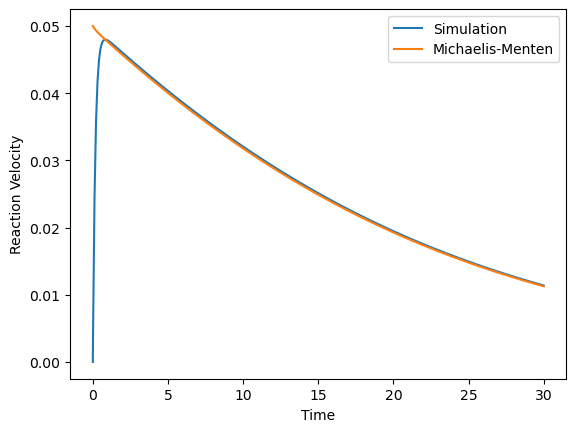

In [2]:
v_max = k2 * (E[0] + ES[0])
Km = (k1m + k2) / k1p

v_sim = k2 * ES
v_mm = v_max * S / (Km + S)

plt.plot(t, v_sim, label="Simulation")
plt.plot(t, v_mm, label="Michaelis-Menten")
plt.xlabel("Time")
plt.ylabel("Reaction Velocity")
plt.legend()
plt.show()